# Funciones de Transferencia ITAE Óptimas

Función para generar funciones de transferencia con criterio ITAE (Integral of Time-weighted Absolute Error) para sistemas de control con cero error de posición o cero error de velocidad.

In [1]:
import control as ctrl
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math


# !rm -f ubicarpolos.py && wget -O ubicarpolos.py https://raw.githubusercontent.com/nebisman/control-material/refs/heads/main/notebooks/ubicarpolos.py
from ubicarpolos import asigne_polos, calcular_itae, tf_to_latex

## Ejemplo de uso con respuesta al escalón

<IPython.core.display.Math object>

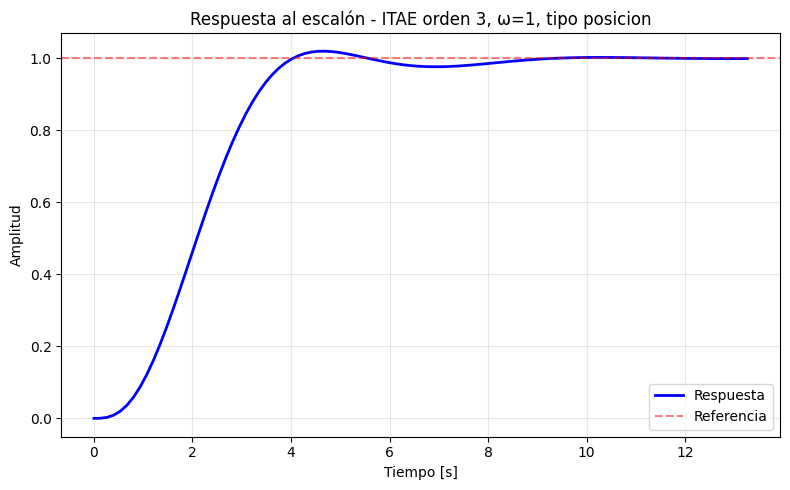

In [7]:
# Ejemplo: función ITAE de orden 3, omega=1, tipo 'p'
T = calcular_itae(orden=3, omega=1, tipo="p")
display(Math(tf_to_latex(T)))


# Respuesta al escalón
t, y = ctrl.step_response(T)

#comandos de la figura
plt.figure(figsize=(8, 5))
plt.plot(t, y, 'b-', linewidth=2)
plt.axhline(y=1, color='r', linestyle='--', alpha=0.5, label='Referencia')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Respuesta al escalón - ITAE orden 3, ω=1, tipo posicion')
plt.legend(['Respuesta', 'Referencia'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Respuesta al escalón para ITAE orden 3, de posición, con ω = 1, 2,3, 5, 10

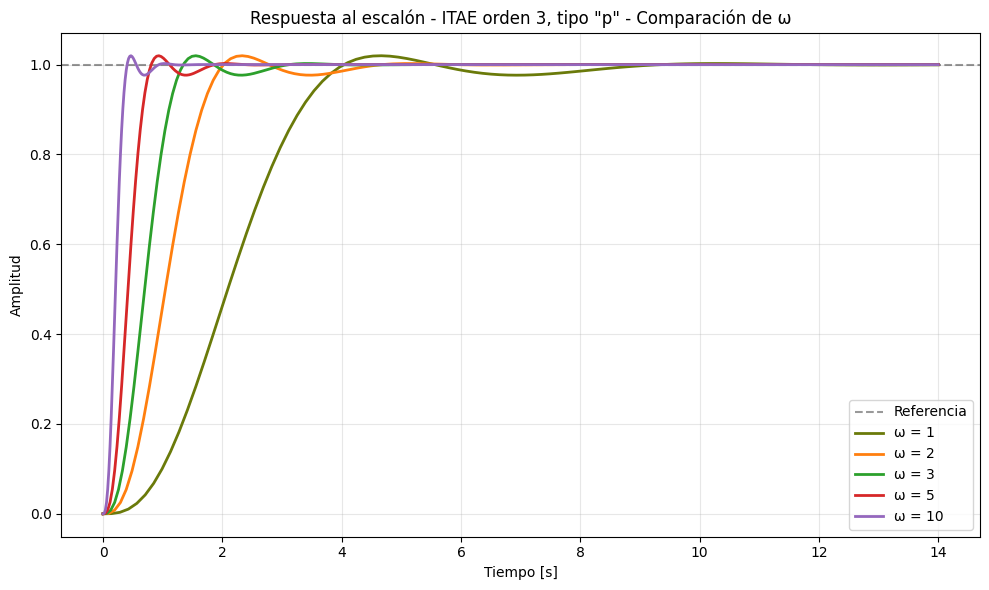

In [9]:
omegas = [1, 2,3, 5,10]
colores = ["#6a7a0a", '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

plt.figure(figsize=(10, 6))
plt.axhline(y=1, color='k', linestyle='--', alpha=0.4, label='Referencia')

for omega, color in zip(omegas, colores):
    T = calcular_itae(orden=3, omega=omega, tipo="p")
    t, y = ctrl.step_response(T, 14)
    plt.plot(t, y, color=color, linewidth=2, label=f'ω = {omega}')

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Respuesta al escalón - ITAE orden 3, tipo "p" - Comparación de ω')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Funciones de transferencia ITAE de posición (órdenes 1 a 6)

La forma general de la función de transferencia ITAE óptima para **cero error de posición** es:

$$T(s) = \frac{\omega_0^{\,n}}{s^n + a_{n-1}\,\omega_0\, s^{n-1} + a_{n-2}\,\omega_0^2\, s^{n-2} + \cdots + a_1\,\omega_0^{n-1}\, s + \omega_0^n}$$

| Orden | Función de transferencia $T(s)$ |
|:-----:|:-------------------------------:|
| 1 | $\dfrac{\omega_0}{s + \omega_0}$ |
| 2 | $\dfrac{\omega_0^2}{s^2 + 1.4\,\omega_0\, s + \omega_0^2}$ |
| 3 | $\dfrac{\omega_0^3}{s^3 + 1.75\,\omega_0\, s^2 + 2.15\,\omega_0^2\, s + \omega_0^3}$ |
| 4 | $\dfrac{\omega_0^4}{s^4 + 2.1\,\omega_0\, s^3 + 3.4\,\omega_0^2\, s^2 + 2.7\,\omega_0^3\, s + \omega_0^4}$ |
| 5 | $\dfrac{\omega_0^5}{s^5 + 2.8\,\omega_0\, s^4 + 5.0\,\omega_0^2\, s^3 + 5.5\,\omega_0^3\, s^2 + 3.4\,\omega_0^4\, s + \omega_0^5}$ |
| 6 | $\dfrac{\omega_0^6}{s^6 + 3.25\,\omega_0\, s^5 + 6.6\,\omega_0^2\, s^4 + 8.6\,\omega_0^3\, s^3 + 7.45\,\omega_0^4\, s^2 + 3.95\,\omega_0^5\, s + \omega_0^6}$ |

<>:15: SyntaxWarning: invalid escape sequence '\o'
<>:15: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_284165/3111527200.py:15: SyntaxWarning: invalid escape sequence '\o'
  plt.title('Respuesta al escalón — ITAE de posición ($\omega=1$) — Órdenes 1 a 6')


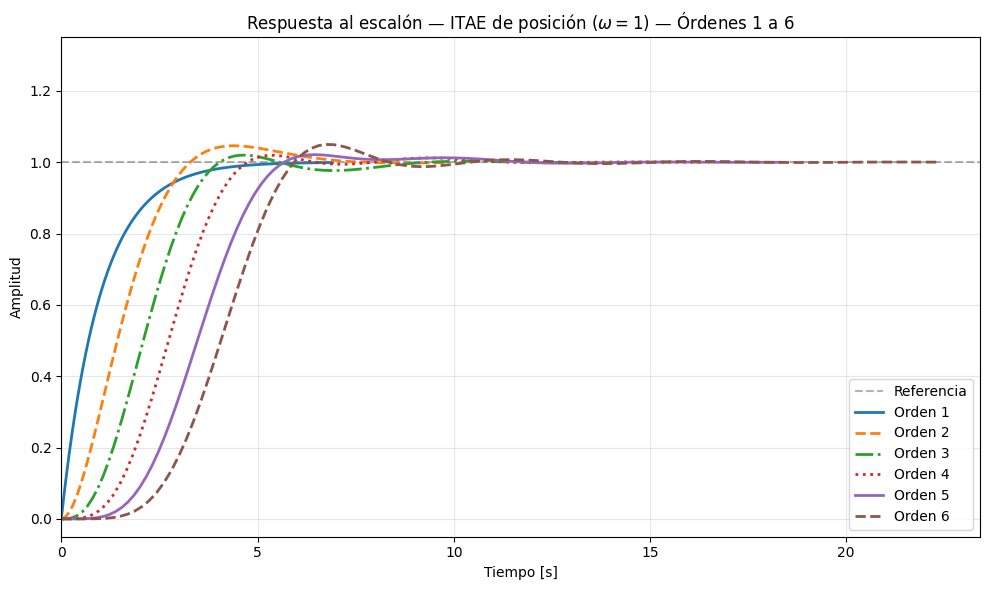

In [10]:
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
estilos = ['-', '--', '-.', ':', '-', '--']

plt.figure(figsize=(10, 6))
plt.axhline(y=1, color='k', linestyle='--', alpha=0.3, label='Referencia')

for n in range(1, 7):
    T = calcular_itae(orden=n, omega=1, tipo="p")
    t, y = ctrl.step_response(T)
    plt.plot(t, y, color=colores[n-1], linestyle=estilos[n-1],
             linewidth=2, label=f'Orden {n}')

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Respuesta al escalón — ITAE de posición ($\omega=1$) — Órdenes 1 a 6')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.xlim(left=0)
plt.ylim(-0.05, 1.35)
plt.tight_layout()
plt.show()